<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/EDA_ML_Storms.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 1 — Text is data: storm narratives
- Where we are: M4 was numbers in order. M5.1 treats text as a BAG OF WORDS - word order is thrown away, we count words and hand them to models you already know. M5.2 keeps the order (embeddings + RNNs).
- NOAA Storm Events 2019: 61,324 events x 28 columns. Label = EVENT_TYPE. Two text columns: EVENT_NARRATIVE (this storm) vs EPISODE_NARRATIVE (the whole outbreak, shared by many rows) - we use EVENT.
- 13,000 events have no narrative: drop them -> 48,324 left.
- Keep storm types with at least 300 events (bar plot), then pick two well-represented classes: Hail (3,783) vs Flash Flood (3,851).
- Traditional EDA on hail first: 1 direct injury and 0 deaths in 3,783 storms.
- DAMAGE_CROPS is TEXT ('0.00K', '5.00M'): strip the K/M and multiply. Median $0, 97.5th percentile $100, max $5M - the quantile table tells the story the histogram can't.
-->

# EDA and ML for Storm Classification Data
**Dr. Dave Wanik - University of Connecticut**

*Thanks to my former student Vineela Datla for sharing data and ideas for this example!*

In this project, the goal is to be able to classify text. The data is from the NOAA website that has descriptive data about the storm events.
https://www1.ncdc.noaa.gov/pub/data/swdi/stormevents/csvfiles/

This example can generalize to ANY text classification problem and EDA you want to solve - so long as your data is stored in a .csv, you can use most of this code directly with only light editing.

In [1]:
# import modules
import numpy as np
import pandas as pd

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# need to add nltk imports up here
# link: https://www.nltk.org/
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dww05002\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

We read in the data and see this has a traditional database output, with some limited numeric columns. The best data is all the way to the right (comment fields!)

In the old days, I would've deleted these things since I had no use for them - but now, with all of the open-source software available, you can really bring that data to life and 1) not only explore it but 2) build models with it! Let's get to work.

In [2]:
# we will read the file directly from this link
# url = "https://drive.google.com/uc?export=download&id=1jvIwUFVMZE7bQwGQeiu1yT6CSIdieu6_"

# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module5_Files/data/StormEvents_2019.csv"

dataframe = pd.read_csv(url, header = 0) # this means there is a header in the first row
storm_df = pd.DataFrame(dataframe)
print(storm_df.shape) # woah! 60K rows and 28 columns, very nice.
storm_df.head()

(61324, 28)


,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,137295,824116,TEXAS,48,2019,May,Flash Flood,BEXAR,5/9/2019 15:54,CST-6,...,N,LEON SPGS,NNE,SAN GERONIMO,29.7898,-98.6406,29.7158,-98.7744,Thunderstorms developed along a cold front as ...,Thunderstorms produced heavy rain that led to ...
1,140217,843354,MINNESOTA,27,2019,July,Thunderstorm Wind,PINE,7/15/2019 16:40,CST-6,...,E,ROCK CREEK,E,ROCK CREEK,45.7700,-92.8700,45.7700,-92.8700,An area of low pressure over southern Manitoba...,A 14-inch tree fell due to the winds and damag...
2,142648,861581,TEXAS,48,2019,October,Thunderstorm Wind,VAN ZANDT,10/20/2019 22:23,CST-6,...,N,EDGEWOOD,N,EDGEWOOD,32.7100,-95.8800,32.7100,-95.8800,Thunderstorms erupted across the DFW Metroplex...,A trained spotter measured a wind gust of 67 M...
3,142648,861584,TEXAS,48,2019,October,Thunderstorm Wind,TARRANT,10/20/2019 23:12,CST-6,...,WSW,AZLE,WSW,AZLE,32.8700,-97.6100,32.8700,-97.6100,Thunderstorms erupted across the DFW Metroplex...,The local police department reported a wind gu...
4,142648,861582,TEXAS,48,2019,October,Thunderstorm Wind,PALO PINTO,10/20/2019 22:36,CST-6,...,N,MINERAL WELLS,N,MINERAL WELLS,32.8000,-98.1000,32.8000,-98.1000,Thunderstorms erupted across the DFW Metroplex...,A wind gust of 75 MPH was measured by the Auto...


Let's look at a sample text examples. There is a detailed column (EPISODE_NARRATIVE) and a more concise column (EVENT_NARRATIVE).

In [3]:
# there's a more detailed column called "EPISODE_NARRATIVE"
print(storm_df['EPISODE_NARRATIVE'][0])
print(storm_df['EPISODE_NARRATIVE'][1])
print(storm_df['EPISODE_NARRATIVE'][2])

Thunderstorms developed along a cold front as it moved through South Central Texas. Some of these storms produced large hail, damaging wind gusts, and heavy rain that led to flash flooding.
An area of low pressure over southern Manitoba the morning of the 15th moved to near southern Hudson Bay by the morning of the 16th. A cold front associated with this low moved across the Northland during the afternoon and evening hours of the 15th. A warm front had moved through on the previous day brought a warm and unstable airmass in its wake. The cold front then worked with this airmass to create severe storms from northeast Minnesota into northwest Wisconsin and western Lake Superior. Damaging winds accounted for most of the reports with these storms, although there was some marginally severe hail as well. Most of the damage was to trees, but some property damage to pontoon boats and a home also occurred.
Thunderstorms erupted across the DFW Metroplex as a strong upper level system and a cold 

In [4]:
# first observations from storm_df['EVENT_NARRATIVE']
print(storm_df['EVENT_NARRATIVE'][0])
print(storm_df['EVENT_NARRATIVE'][1])
print(storm_df['EVENT_NARRATIVE'][2])

Thunderstorms produced heavy rain that led to flash flooding. Multiple low water crossings were closed in northwestern Bexar County.
A 14-inch tree fell due to the winds and damaged a garage, vehicle and a light pole.
A trained spotter measured a wind gust of 67 MPH approximately one mile north of the city of Edgewood, TX.


As we are trying to classify event type based on the narrative, lets get rid of the rows where the data narrative is not available

In [5]:
# Checking for null values in event narrative column
storm_df.info()

# the data is MOSTLY good but has some nulls, so we drop it.

<class 'pandas.DataFrame'>
RangeIndex: 61324 entries, 0 to 61323
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EPISODE_ID         61324 non-null  int64  
 1   EVENT_ID           61324 non-null  int64  
 2   STATE              61324 non-null  str    
 3   STATE_FIPS         61324 non-null  int64  
 4   YEAR               61324 non-null  int64  
 5   MONTH_NAME         61324 non-null  str    
 6   EVENT_TYPE         61324 non-null  str    
 7   CZ_NAME            61324 non-null  str    
 8   BEGIN_DATE_TIME    61324 non-null  str    
 9   CZ_TIMEZONE        61324 non-null  str    
 10  END_DATE_TIME      61324 non-null  str    
 11  INJURIES_DIRECT    61324 non-null  int64  
 12  INJURIES_INDIRECT  61324 non-null  int64  
 13  DEATHS_DIRECT      61324 non-null  int64  
 14  DEATHS_INDIRECT    61324 non-null  int64  
 15  DAMAGE_PROPERTY    49501 non-null  str    
 16  DAMAGE_CROPS       49928 non-null

In [6]:
# Dropping rows where event narrative is empty...
event_df = storm_df.dropna(subset=['EVENT_NARRATIVE'])
print(event_df.shape) # now we have 48K rows
event_df.head()

(48324, 28)


,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,137295,824116,TEXAS,48,2019,May,Flash Flood,BEXAR,5/9/2019 15:54,CST-6,...,N,LEON SPGS,NNE,SAN GERONIMO,29.7898,-98.6406,29.7158,-98.7744,Thunderstorms developed along a cold front as ...,Thunderstorms produced heavy rain that led to ...
1,140217,843354,MINNESOTA,27,2019,July,Thunderstorm Wind,PINE,7/15/2019 16:40,CST-6,...,E,ROCK CREEK,E,ROCK CREEK,45.7700,-92.8700,45.7700,-92.8700,An area of low pressure over southern Manitoba...,A 14-inch tree fell due to the winds and damag...
2,142648,861581,TEXAS,48,2019,October,Thunderstorm Wind,VAN ZANDT,10/20/2019 22:23,CST-6,...,N,EDGEWOOD,N,EDGEWOOD,32.7100,-95.8800,32.7100,-95.8800,Thunderstorms erupted across the DFW Metroplex...,A trained spotter measured a wind gust of 67 M...
3,142648,861584,TEXAS,48,2019,October,Thunderstorm Wind,TARRANT,10/20/2019 23:12,CST-6,...,WSW,AZLE,WSW,AZLE,32.8700,-97.6100,32.8700,-97.6100,Thunderstorms erupted across the DFW Metroplex...,The local police department reported a wind gu...
4,142648,861582,TEXAS,48,2019,October,Thunderstorm Wind,PALO PINTO,10/20/2019 22:36,CST-6,...,N,MINERAL WELLS,N,MINERAL WELLS,32.8000,-98.1000,32.8000,-98.1000,Thunderstorms erupted across the DFW Metroplex...,A wind gust of 75 MPH was measured by the Auto...


We can make a nice barplot of the different storm types.

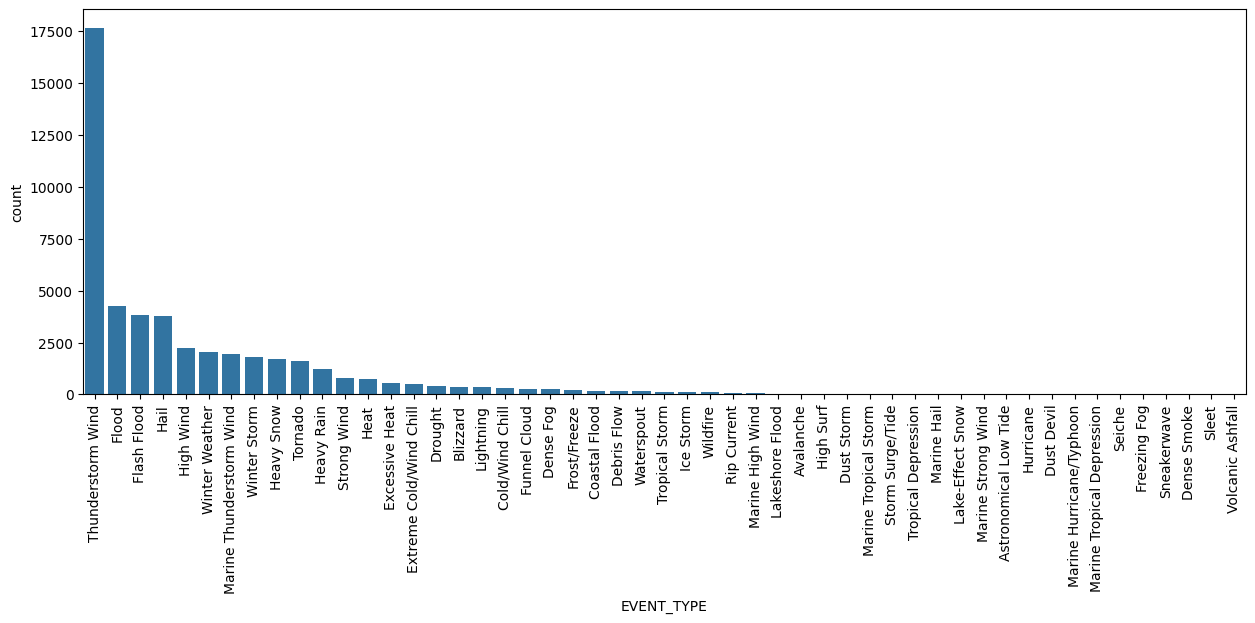

In [7]:
# to sort by frequency...
# link: https://stackoverflow.com/questions/46623583/seaborn-countplot-order-categories-by-count

plt.figure(figsize=(15,5))
ax = sns.countplot(x="EVENT_TYPE", data=event_df,
                   order = event_df['EVENT_TYPE'].value_counts().index)
ax.tick_params(axis='x', labelrotation=90)   # rotate the storm names so they don't overlap
plt.show()

In [8]:
# subset those storms that have at least 300 observations
final_df = event_df[event_df.groupby("EVENT_TYPE")["EVENT_ID"].transform('count')>300]
final_df.groupby("EVENT_TYPE")["EVENT_ID"].count()

EVENT_TYPE
Blizzard                      345
Cold/Wind Chill               308
Drought                       421
Excessive Heat                553
Extreme Cold/Wind Chill       526
Flash Flood                  3851
Flood                        4253
Hail                         3783
Heat                          733
Heavy Rain                   1235
Heavy Snow                   1718
High Wind                    2240
Lightning                     336
Marine Thunderstorm Wind     1971
Strong Wind                   773
Thunderstorm Wind           17659
Tornado                      1621
Winter Storm                 1824
Winter Weather               2054
Name: EVENT_ID, dtype: int64

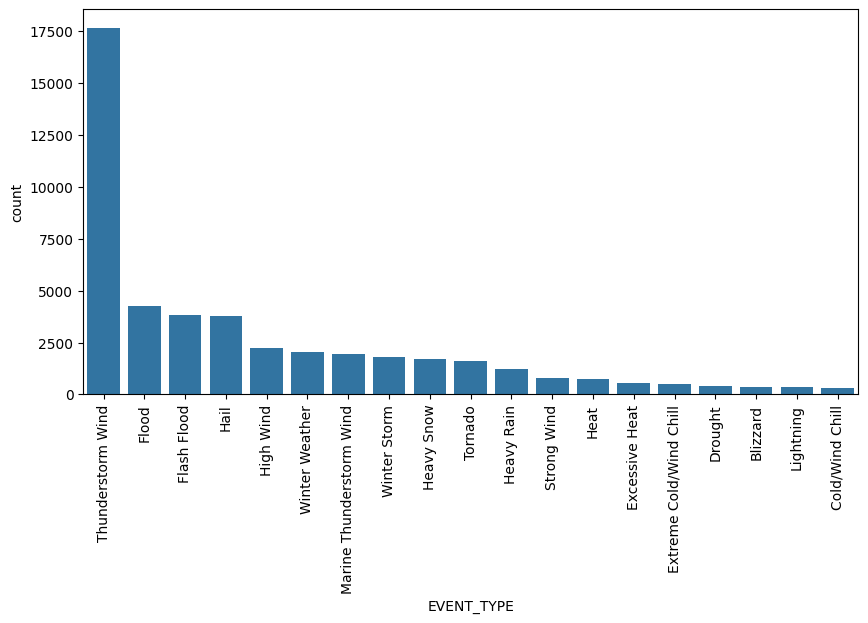

In [9]:
# show a plot of the different categories (count of obserations)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
ax = sns.countplot(x="EVENT_TYPE", data=final_df,
                   order = final_df['EVENT_TYPE'].value_counts().index)
ax.tick_params(axis='x', labelrotation=90)   # rotate the storm names so they don't overlap
plt.show()

Remember, we've made three different versions of the data now:
* storm_df (original data)
* event_df (has only complete rows for text data)
* final_df (contains storms with as least 300 counts)

# Exploring the text data
Let's compare hail storms and flash floods and see what's going on.

# Subset Hail data
First things first - let's take a peak at just the hail storms.

In [10]:
hail_df = final_df[final_df['EVENT_TYPE']=='Hail']
hail_df.info() # looks like there are 3783 hail storms

<class 'pandas.DataFrame'>
Index: 3783 entries, 6 to 61237
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EPISODE_ID         3783 non-null   int64  
 1   EVENT_ID           3783 non-null   int64  
 2   STATE              3783 non-null   str    
 3   STATE_FIPS         3783 non-null   int64  
 4   YEAR               3783 non-null   int64  
 5   MONTH_NAME         3783 non-null   str    
 6   EVENT_TYPE         3783 non-null   str    
 7   CZ_NAME            3783 non-null   str    
 8   BEGIN_DATE_TIME    3783 non-null   str    
 9   CZ_TIMEZONE        3783 non-null   str    
 10  END_DATE_TIME      3783 non-null   str    
 11  INJURIES_DIRECT    3783 non-null   int64  
 12  INJURIES_INDIRECT  3783 non-null   int64  
 13  DEATHS_DIRECT      3783 non-null   int64  
 14  DEATHS_INDIRECT    3783 non-null   int64  
 15  DAMAGE_PROPERTY    2796 non-null   str    
 16  DAMAGE_CROPS       2862 non-null   str 

# Traditional EDA on the Hail Data
How many injuries and deaths were there? What was the damage to property and crops? The injury and death data is int64 (numeric), but we will need to wrangle the property and crop data (it's stored as a string, because there a K and M at the end of the number!)

### Injuries and Deaths

In [11]:
# injuries and deaths - all four columns at once
hail_df[['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT']].sum() # hardly any, and no deaths!

INJURIES_DIRECT      1
INJURIES_INDIRECT    3
DEATHS_DIRECT        0
DEATHS_INDIRECT      0
dtype: int64

### Property and Crop Damage
Are these storms destructive?

In [12]:
# any property damage?
# whoa, this doesn't look right... maybe need to convert to numeric
hail_df[['DAMAGE_CROPS', 'DAMAGE_PROPERTY']].describe()

,DAMAGE_CROPS,DAMAGE_PROPERTY
count,2862,2796
unique,23,54
top,0.00K,0.00K
freq,2772,2483


In [13]:
# what is going on with DAMAGE_PROPERTY and DAMAGE_CROPS?
hail_df[['DAMAGE_PROPERTY', 'DAMAGE_CROPS']].head()

,DAMAGE_PROPERTY,DAMAGE_CROPS
6,0.00K,0.00K
20,0.00K,0.00K
21,0.00K,0.00K
31,0.00K,0.00K
42,0.00K,0.00K


In [14]:
# here is how to convert the field
# you replace K and/or M with just an empty strings
# then you can multiply by 10^3 for K, and 10^6 for M
# hacked this example: https://stackoverflow.com/questions/39684548/convert-the-string-2-90k-to-2900-or-5-2m-to-5200000-in-pandas-dataframe
hail_df['DAMAGE_CROPS'] = (hail_df['DAMAGE_CROPS'].replace(r'[KM]+$', '', regex=True).astype(float) * \
              hail_df['DAMAGE_CROPS'].str.extract(r'[\d\.]+([KM]+)', expand=False)
                .fillna(1)
                .replace(['K','M'], [10**3, 10**6]).astype(int))
hail_df['DAMAGE_CROPS'].describe()

count    2.862000e+03
mean     6.382855e+03
std      1.166219e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+06
Name: DAMAGE_CROPS, dtype: float64

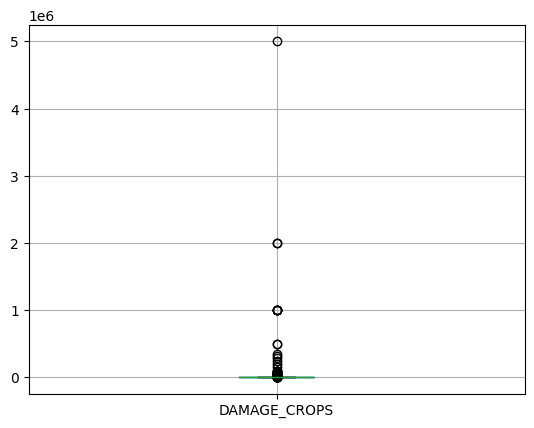

In [15]:
# visualize it! not great a plot... what can we do to inspect tails?
hail_df.boxplot(['DAMAGE_CROPS'])
plt.show()

In [16]:
# one more table - better story!
hail_df['DAMAGE_CROPS'].quantile([0.8, 0.9, 0.95, 0.975, 0.99, 0.999, 1])

# we are looking at the tail, and we see that in:
# 97.5% of cases, there is only 100 dollars of damage or less
# but there is a 1% chance that there will be 50K or more in damage to crops!
# and there is a 0.1% chance that there will be 1M damage or more to crops!

# you have to be curious about this stuff and dig deep, especially when the your
# visualization is not as useful as you would've hoped

# the tails/extremes are the most interesting!

0.800          0.0
0.900          0.0
0.950          0.0
0.975        100.0
0.990      50000.0
0.999    1139000.0
1.000    5000000.0
Name: DAMAGE_CROPS, dtype: float64

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 2 — Cleaning text: lowercase, strip, stop words, tokenize, stem
- Vocabulary: the CORPUS is all the narratives, a DOCUMENT is one narrative.
- Lowercase so 'Hail' = 'hail'. Then strip everything but letters and spaces.
- ⚠️ regex=True on that strip line: since pandas 2.0, str.replace treats the pattern as plain text, so the 2022 line silently did NOTHING (periods and commas survived). And [^a-zA-Z ] not [^A-z ] - the A-z range sneaks in [ \ ] ^ _ and the backtick.
- Stop words (NLTK's list - show it): 'trained spotter reported hail up to the size of quarters...' -> 'trained spotter reported hail size quarters along heavy rain standing water yard'.
- remove_stopwords and stem_words are FUNCTIONS with a plain for loop inside: written once here, reused for flood next video.
- Most common words: hail 3,611, reported 1,955, size 1,862, quarter 1,037. 'hail' is the LABEL hiding in the text - a leakage word (the cell shows how to add it to the stop list).
- Word cloud, then nltk.word_tokenize (a list of words), then stemming: trained -> train, heavy -> heavi, standing -> stand. Worth it when words >> rows; we skip it for deep learning.
-->

# Dig into the Event Narrative
We can build models for classification based on Episode Narrative or Event Narrative! Let's explore!!!

In [17]:
# reset the index just so it looks nice
hail_df.reset_index(inplace=True)
hail_df.head()

,index,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,6,141212,848333,VERMONT,50,2019,September,Hail,WINDSOR,9/4/2019 12:29,...,W,LUDLOW,W,LUDLOW,43.40,-72.72,43.40,-72.72,A strong mid-level disturbance and cold front ...,Quarter size hail reported at Okemo Ski resort.
1,20,139926,844159,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:37,...,ENE,FROID,ENE,FROID,48.39,-104.26,48.39,-104.26,Plentiful surface moisture from the southeast ...,Trained spotter reported hail up to the size o...
2,21,139926,844160,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:50,...,ENE,FROID,ENE,FROID,48.39,-104.29,48.39,-104.29,Plentiful surface moisture from the southeast ...,"Public reported, via social media, quarter siz..."
3,31,139926,844158,MONTANA,30,2019,September,Hail,SHERIDAN,9/2/2019 7:27,...,WSW,PLENTYWOOD,WSW,PLENTYWOOD,48.72,-104.74,48.72,-104.74,Plentiful surface moisture from the southeast ...,Public reported quarter size hail.
4,42,141962,852318,CONNECTICUT,9,2019,September,Hail,HARTFORD,9/4/2019 16:10,...,N,ENFIELD,N,ENFIELD,41.97,-72.57,41.97,-72.57,A cold front pushed through southern New Engla...,Dime size hail was reported in Enfield.


In [18]:
# get rid of the original index column
del hail_df['index']
print(hail_df.shape)
hail_df.head()

(3783, 28)


,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,141212,848333,VERMONT,50,2019,September,Hail,WINDSOR,9/4/2019 12:29,EST-5,...,W,LUDLOW,W,LUDLOW,43.40,-72.72,43.40,-72.72,A strong mid-level disturbance and cold front ...,Quarter size hail reported at Okemo Ski resort.
1,139926,844159,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:37,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.26,48.39,-104.26,Plentiful surface moisture from the southeast ...,Trained spotter reported hail up to the size o...
2,139926,844160,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:50,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.29,48.39,-104.29,Plentiful surface moisture from the southeast ...,"Public reported, via social media, quarter siz..."
3,139926,844158,MONTANA,30,2019,September,Hail,SHERIDAN,9/2/2019 7:27,MST-7,...,WSW,PLENTYWOOD,WSW,PLENTYWOOD,48.72,-104.74,48.72,-104.74,Plentiful surface moisture from the southeast ...,Public reported quarter size hail.
4,141962,852318,CONNECTICUT,9,2019,September,Hail,HARTFORD,9/4/2019 16:10,EST-5,...,N,ENFIELD,N,ENFIELD,41.97,-72.57,41.97,-72.57,A cold front pushed through southern New Engla...,Dime size hail was reported in Enfield.


### Lowercase
There is no difference between the words "HAIL", "Hail" and "hail"...
To make our analysis more meaningful, we make all of these words lowercase.

In [19]:
# before we get started, here are the first three rows
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

Quarter size hail reported at Okemo Ski resort.
Trained spotter reported hail up to the size of quarters, along with heavy rain and standing water in their yard.
Public reported, via social media, quarter size hail.


In [20]:
# make everything lowercase
hail_df['EVENT_NARRATIVE'] = hail_df['EVENT_NARRATIVE'].str.lower()
hail_df.head()

,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,141212,848333,VERMONT,50,2019,September,Hail,WINDSOR,9/4/2019 12:29,EST-5,...,W,LUDLOW,W,LUDLOW,43.40,-72.72,43.40,-72.72,A strong mid-level disturbance and cold front ...,quarter size hail reported at okemo ski resort.
1,139926,844159,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:37,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.26,48.39,-104.26,Plentiful surface moisture from the southeast ...,trained spotter reported hail up to the size o...
2,139926,844160,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:50,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.29,48.39,-104.29,Plentiful surface moisture from the southeast ...,"public reported, via social media, quarter siz..."
3,139926,844158,MONTANA,30,2019,September,Hail,SHERIDAN,9/2/2019 7:27,MST-7,...,WSW,PLENTYWOOD,WSW,PLENTYWOOD,48.72,-104.74,48.72,-104.74,Plentiful surface moisture from the southeast ...,public reported quarter size hail.
4,141962,852318,CONNECTICUT,9,2019,September,Hail,HARTFORD,9/4/2019 16:10,EST-5,...,N,ENFIELD,N,ENFIELD,41.97,-72.57,41.97,-72.57,A cold front pushed through southern New Engla...,dime size hail was reported in enfield.


In [21]:
# here's an example of what we did
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

quarter size hail reported at okemo ski resort.
trained spotter reported hail up to the size of quarters, along with heavy rain and standing water in their yard.
public reported, via social media, quarter size hail.


### Strip funky characters (!,~-@$% etc)
Funky characters can be a pain - they make words appear to be unique (think of trouble with strings). Let's ditch 'em!

In [22]:
# remove any funky characters with a blank
# regex=True matters: since pandas 2.0, str.replace treats the pattern as plain text unless you say so
# (and [^a-zA-Z ] not [^A-z ] - the A-z range sneaks in [ \ ] ^ _ and the backtick)
hail_df['EVENT_NARRATIVE'] = hail_df['EVENT_NARRATIVE'].str.replace('[^a-zA-Z ]', '', regex=True).str.replace(' +', ' ', regex=True).str.strip()
hail_df.head()

,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,141212,848333,VERMONT,50,2019,September,Hail,WINDSOR,9/4/2019 12:29,EST-5,...,W,LUDLOW,W,LUDLOW,43.40,-72.72,43.40,-72.72,A strong mid-level disturbance and cold front ...,quarter size hail reported at okemo ski resort
1,139926,844159,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:37,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.26,48.39,-104.26,Plentiful surface moisture from the southeast ...,trained spotter reported hail up to the size o...
2,139926,844160,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:50,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.29,48.39,-104.29,Plentiful surface moisture from the southeast ...,public reported via social media quarter size ...
3,139926,844158,MONTANA,30,2019,September,Hail,SHERIDAN,9/2/2019 7:27,MST-7,...,WSW,PLENTYWOOD,WSW,PLENTYWOOD,48.72,-104.74,48.72,-104.74,Plentiful surface moisture from the southeast ...,public reported quarter size hail
4,141962,852318,CONNECTICUT,9,2019,September,Hail,HARTFORD,9/4/2019 16:10,EST-5,...,N,ENFIELD,N,ENFIELD,41.97,-72.57,41.97,-72.57,A cold front pushed through southern New Engla...,dime size hail was reported in enfield


In [23]:
# let's see what we did, no commas or periods!!!
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

quarter size hail reported at okemo ski resort
trained spotter reported hail up to the size of quarters along with heavy rain and standing water in their yard
public reported via social media quarter size hail


### Stop words
'Stop words' are simply common words in the English language - they are not special and generally don't convey too much information. So it's best to get rid of them.

In [24]:
# let's remove some of the stop words (see what happens if you comment this cell out)
# we can do better!
# define some stop words
import nltk
from nltk.corpus import stopwords


nltk.download('stopwords') # this makes sure these are downloaded if you haven't already!
print(stopwords.words('english'))

stop = stopwords.words('english') # see why it's important to turn everything lower case? all of your stopwords are!

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dww05002\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
# remove the stop words
# apply these stopwords to the data
# link: https://stackoverflow.com/questions/29523254/python-remove-stop-words-from-pandas-dataframe/43407993

# this looks good!
# ' '. adds a nice space (try adding a 'D' instead of ' ' and see what happens!)
hail_df.head() # note how the stop words have been removed
def remove_stopwords(text):
    """Keep every word that is NOT a stop word, then glue them back together with spaces."""
    kept = []
    for word in text.split():
        if word not in stop:
            kept.append(word)
    return ' '.join(kept)      # ' '. adds a nice space (try adding a 'D' instead of ' ' and see what happens!)

hail_df["EVENT_NARRATIVE"] = hail_df['EVENT_NARRATIVE'].apply(remove_stopwords)
hail_df.head()

,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,141212,848333,VERMONT,50,2019,September,Hail,WINDSOR,9/4/2019 12:29,EST-5,...,W,LUDLOW,W,LUDLOW,43.40,-72.72,43.40,-72.72,A strong mid-level disturbance and cold front ...,quarter size hail reported okemo ski resort
1,139926,844159,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:37,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.26,48.39,-104.26,Plentiful surface moisture from the southeast ...,trained spotter reported hail size quarters al...
2,139926,844160,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:50,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.29,48.39,-104.29,Plentiful surface moisture from the southeast ...,public reported via social media quarter size ...
3,139926,844158,MONTANA,30,2019,September,Hail,SHERIDAN,9/2/2019 7:27,MST-7,...,WSW,PLENTYWOOD,WSW,PLENTYWOOD,48.72,-104.74,48.72,-104.74,Plentiful surface moisture from the southeast ...,public reported quarter size hail
4,141962,852318,CONNECTICUT,9,2019,September,Hail,HARTFORD,9/4/2019 16:10,EST-5,...,N,ENFIELD,N,ENFIELD,41.97,-72.57,41.97,-72.57,A cold front pushed through southern New Engla...,dime size hail reported enfield


In [26]:
# let's see what we did, no commas or periods!!!
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

quarter size hail reported okemo ski resort
trained spotter reported hail size quarters along heavy rain standing water yard
public reported via social media quarter size hail


# Text EDA on the Hail Data

### Most common words
Word clouds and frequency tables/plots.

In [27]:
# 1) what are the most common words in the EVENT_NARRATIVE? note that we are doing this before tokenizer
# you can also turn this into a bar plot!
myTable = hail_df['EVENT_NARRATIVE'].str.split(expand=True).stack().value_counts()
myTable[0:20] # too cool!

hail        3611
reported    1955
size        1862
quarter     1037
sized        678
ball         514
report       461
near         425
spotter      416
inch         397
golf         384
fell         377
trained      356
public       349
diameter     343
media        341
nickel       294
city         285
social       263
tx           253
Name: count, dtype: int64

In [28]:
# and we can make a frequency plot
# we'll group, then convert to pandas DataFrame for easy plotting
x = hail_df['EVENT_NARRATIVE'].str.split(expand=True).stack().value_counts()
x = pd.DataFrame(x)
# reset the index
x.reset_index(inplace=True)
# rename the columns
x.rename(columns={x.columns[0]:'word', x.columns[1]:'frequency'}, inplace=True)
x.head()

,word,frequency
0,hail,3611
1,reported,1955
2,size,1862
3,quarter,1037
4,sized,678


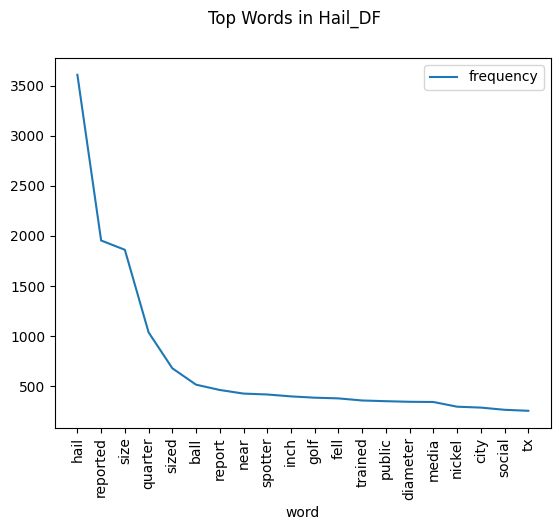

In [29]:
# Frequency Distribution Plot
# look at first X words

# len(x) just the number of rows

x = x[0:20] # wanna play? change the 20 to 10 or 30 and see what happens...
            # you need to run the previous cell first
x.plot(x='word', y='frequency')
plt.xticks(np.arange(len(x)), x['word'], rotation=90)
plt.suptitle('Top Words in Hail_DF')
plt.show()


In [30]:
# # if we wanted to, we could delete 'hail' so that the model isn't cheating!
# # to do this, we just need to append our stop words...

# # i will keep this commented out for now, but it's possible to do this and repeat the notebook!

# # not shown here, but like this
# # link: https://stackabuse.com/removing-stop-words-from-strings-in-python/#:~:text=Using%20Python's%20NLTK%20Library&text=NLTK%20supports%20stop%20word%20removal,stop%20words%20provided%20by%20NLTK.

# # import
# nltk.download('punkt')
# from nltk.tokenize import word_tokenize

# sw_list = ['hail']
# stop.extend(sw_list)

# text_tokens = word_tokenize(str(hail_df["EVENT_NARRATIVE"]))
# tokens_without_sw = [word for word in text_tokens if not word in stop]

# print(tokens_without_sw) # see, now hail is gone!!!
# # would the model do just as well without hail in the description?

### Word Cloud
Instead of just word frequency, you can get a nice graphic like this! Words that are most common are large. You can read more about customization here:
https://www.datacamp.com/community/tutorials/wordcloud-python

You can be creative here!!!

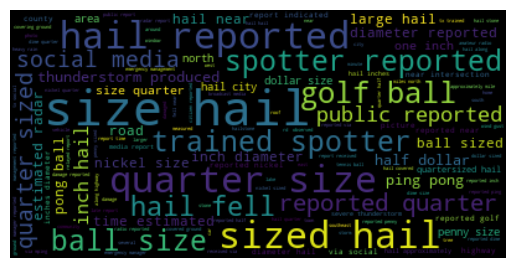

In [31]:
# https://amueller.github.io/word_cloud/auto_examples/simple.html#sphx-glr-auto-examples-simple-py

from wordcloud import WordCloud

# Generate a word cloud image
wordcloud = WordCloud().generate(' '.join(hail_df['EVENT_NARRATIVE']))

# # Display the generated image:
# # the matplotlib way:
# import matplotlib.pyplot as plt
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")

# lower max_font_size
wordcloud = WordCloud(max_font_size=40).generate(' '.join(hail_df['EVENT_NARRATIVE']))
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Tokenizer
The tokenizer takes a given sentence and parses it into a list with individual words separated by a comma. This makes it easy for us to do some feature engineering later on in the notebook.

In [32]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dww05002\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [33]:
# tokenizer
# hello tokenizer! make this a list with individual entries/values
hail_df['EVENT_NARRATIVE'] = hail_df['EVENT_NARRATIVE'].apply(nltk.word_tokenize)
hail_df.head()
# could also have created a new column?
# link: https://stackoverflow.com/questions/33098040/how-to-use-word-tokenize-in-data-frame

,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_AZIMUTH,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE
0,141212,848333,VERMONT,50,2019,September,Hail,WINDSOR,9/4/2019 12:29,EST-5,...,W,LUDLOW,W,LUDLOW,43.40,-72.72,43.40,-72.72,A strong mid-level disturbance and cold front ...,"[quarter, size, hail, reported, okemo, ski, re..."
1,139926,844159,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:37,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.26,48.39,-104.26,Plentiful surface moisture from the southeast ...,"[trained, spotter, reported, hail, size, quart..."
2,139926,844160,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:50,MST-7,...,ENE,FROID,ENE,FROID,48.39,-104.29,48.39,-104.29,Plentiful surface moisture from the southeast ...,"[public, reported, via, social, media, quarter..."
3,139926,844158,MONTANA,30,2019,September,Hail,SHERIDAN,9/2/2019 7:27,MST-7,...,WSW,PLENTYWOOD,WSW,PLENTYWOOD,48.72,-104.74,48.72,-104.74,Plentiful surface moisture from the southeast ...,"[public, reported, quarter, size, hail]"
4,141962,852318,CONNECTICUT,9,2019,September,Hail,HARTFORD,9/4/2019 16:10,EST-5,...,N,ENFIELD,N,ENFIELD,41.97,-72.57,41.97,-72.57,A cold front pushed through southern New Engla...,"[dime, size, hail, reported, enfield]"


In [34]:
# here's what we did
print(hail_df['EVENT_NARRATIVE'][0])
print(hail_df['EVENT_NARRATIVE'][1])
print(hail_df['EVENT_NARRATIVE'][2])

['quarter', 'size', 'hail', 'reported', 'okemo', 'ski', 'resort']
['trained', 'spotter', 'reported', 'hail', 'size', 'quarters', 'along', 'heavy', 'rain', 'standing', 'water', 'yard']
['public', 'reported', 'via', 'social', 'media', 'quarter', 'size', 'hail']


### Summary
So what did we do? We processed our data to make it all lower case, got rid of funky characters, removed stop words and used the 'tokenizer' to start to parse our text data into something useable. Let's dig into some more examples.

# Lexicon Normalization
This is a fancy word that means we want to take the words (lexicon) and get them in some standardized fashion (normalization). Our goal is to simply the information in our model.

### Stemming
From DataCamp: Stemming is a process of linguistic normalization, which reduces words to their word root word or chops off the derivational affixes. For example, connection, connected, connecting word reduce to a common word "connec".

How can we use this? Use these simpler representations of the words to build your model "connec" (0/1) vs. having three different 0/1 variables for 'connection', 'connected', 'connecting' etc. See where we are going with this? It's all about teaching the computer how to exploit this unstructured data!

In [35]:
# we won't use this today, but sure, it's possible to chop a word down
# this cuts down on dimensionality
# using the example above, three words turn into one "connec"

from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize

# this is the function we will use
ps = PorterStemmer()

filtered_sent = hail_df['EVENT_NARRATIVE'][1]

stemmed_words=[]
for w in filtered_sent:
    stemmed_words.append(ps.stem(w))

print("Filtered Sentence:",filtered_sent)
print("Stemmed Sentence:",stemmed_words)

# in our example, we just got rid of "trained' and 'reported' etc.

Filtered Sentence: ['trained', 'spotter', 'reported', 'hail', 'size', 'quarters', 'along', 'heavy', 'rain', 'standing', 'water', 'yard']
Stemmed Sentence: ['train', 'spotter', 'report', 'hail', 'size', 'quarter', 'along', 'heavi', 'rain', 'stand', 'water', 'yard']


In [36]:
# if we wanted to, we could make a new column with just the stemmed words
# link: https://stackoverflow.com/questions/37443138/python-stemming-with-pandas-dataframe
def stem_words(words):
    """Chop every word in a tokenized row down to its stem."""
    stems = []
    for w in words:
        stems.append(ps.stem(w))
    return stems

hail_df['Stemmed'] = hail_df['EVENT_NARRATIVE'].apply(stem_words) # Stem every word.

In [37]:
# check your work!
print(hail_df['EVENT_NARRATIVE'][0]) # reported
print(hail_df['Stemmed'][0]) # report

print(hail_df['EVENT_NARRATIVE'][10]) # note the difference between inches, reported, covered
print(hail_df['Stemmed'][10]) # inch, report, cover

['quarter', 'size', 'hail', 'reported', 'okemo', 'ski', 'resort']
['quarter', 'size', 'hail', 'report', 'okemo', 'ski', 'resort']
['hail', 'inches', 'reported', 'hail', 'covered', 'ground']
['hail', 'inch', 'report', 'hail', 'cover', 'ground']


It doesn't seem like we get crazy different results between Stemming and the raw data in our example.

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 3 — CountVectorizer and bag of words
- Same recipe on Flash Flood (3,851 rows) - but now it's ONE function, clean_text(), and one line to call it. Ten copy-pasted cells became four. Top flood words: water 2,087, flooding 2,026, road 1,974.
- Stack hail + flood: 7,634 rows. X = the stemmed text glued back into a string, y = EVENT_TYPE.
- Split FIRST, 60/20/20 (seeded): 4,580 / 1,527 / 1,527. The vocabulary is learned from the TRAINING narratives only - otherwise the test set quietly helps build the features it's graded on.
- CountVectorizer = one column per word, the count per document. fit_transform on train (4,984 words); validation and test only get transform().
- SPARSE: 47,333 non-zero cells out of about 23 million (0.2%). That's why it prints as coordinates.
- Toy sentence first, 'the cat sat on the mat': 5 unigrams ('the' counted twice), 5 bigrams ('the cat' and 'the mat' are different features), 4 trigrams - 14 columns from 6 words.
- n-grams put a little order back ('flash flood' as one feature): 4,984 unigrams + 21,059 bigrams + 30,396 trigrams = 56,439 columns for 4,580 rows - far more features than rows.
-->

# Putting it all together (quickly) for Flash Flood
OK so we did a bunch on hail data... let's also look at 'Flash Flood' and create the stemmed words. THEN we will prep our data for modeling and see if we can build a model that can 'read' comments and make a proper classification!

The same logic that we are working through here can apply to sentiment analysis for Twitter or Amazon reviews etc. But notice that right now that all of our data lives nicely curated inside of a pandas dataframe. Later on in your analytics career, you will have to learn to bring all of the these various text sources together (PDFs, Word docs, .csv files, html files etc.)

Data scientist is sometimes more like data janitor, but the adventure of unlocking all of the richness or a dataset is certainly worth it!

## One function: lowercase, strip characters, stop words, tokenize, stem
Same recipe as the hail data - but this time it's written ONCE, as a function. Then it's one line for flood (and one line for any other storm type you want to try).

In [38]:
# subset data
flood_df = final_df[final_df['EVENT_TYPE']=='Flash Flood']
flood_df.info() # looks like there are 3851 floods

<class 'pandas.DataFrame'>
Index: 3851 entries, 0 to 61226
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EPISODE_ID         3851 non-null   int64  
 1   EVENT_ID           3851 non-null   int64  
 2   STATE              3851 non-null   str    
 3   STATE_FIPS         3851 non-null   int64  
 4   YEAR               3851 non-null   int64  
 5   MONTH_NAME         3851 non-null   str    
 6   EVENT_TYPE         3851 non-null   str    
 7   CZ_NAME            3851 non-null   str    
 8   BEGIN_DATE_TIME    3851 non-null   str    
 9   CZ_TIMEZONE        3851 non-null   str    
 10  END_DATE_TIME      3851 non-null   str    
 11  INJURIES_DIRECT    3851 non-null   int64  
 12  INJURIES_INDIRECT  3851 non-null   int64  
 13  DEATHS_DIRECT      3851 non-null   int64  
 14  DEATHS_INDIRECT    3851 non-null   int64  
 15  DAMAGE_PROPERTY    3851 non-null   str    
 16  DAMAGE_CROPS       3851 non-null   str 

In [39]:
def clean_text(df):
    """The whole hail recipe in one place: lowercase, strip, stop words, tokenize, stem."""
    df = df.copy()
    df['EVENT_NARRATIVE'] = df['EVENT_NARRATIVE'].str.lower()
    df['EVENT_NARRATIVE'] = df['EVENT_NARRATIVE'].str.replace('[^a-zA-Z ]', '', regex=True)
    df['EVENT_NARRATIVE'] = df['EVENT_NARRATIVE'].str.replace(' +', ' ', regex=True).str.strip()
    df['EVENT_NARRATIVE'] = df['EVENT_NARRATIVE'].apply(remove_stopwords)
    df['EVENT_NARRATIVE'] = df['EVENT_NARRATIVE'].apply(nltk.word_tokenize)
    df['Stemmed'] = df['EVENT_NARRATIVE'].apply(stem_words)
    return df

In [40]:
# one line!
flood_df = clean_text(flood_df)
flood_df[['EVENT_NARRATIVE', 'Stemmed']].head()

,EVENT_NARRATIVE,Stemmed
0,"[thunderstorms, produced, heavy, rain, led, fl...","[thunderstorm, produc, heavi, rain, led, flash..."
23,"[local, roads, city, streets, multiple, lanes,...","[local, road, citi, street, multipl, lane, wes..."
85,"[redhaw, creek, polk, washed, portion, route, ...","[redhaw, creek, polk, wash, portion, rout, flo..."
89,"[localized, heavy, rain, moved, southern, mari...","[local, heavi, rain, move, southern, marion, c..."
147,"[flash, flooding, occurred, highway, w, past, ...","[flash, flood, occur, highway, w, past, jupit,..."


In [41]:
# most common flood words (explode = one row per word)
flood_words = flood_df['EVENT_NARRATIVE'].explode().value_counts()
flood_words[0:20]

EVENT_NARRATIVE
water       2087
flooding    2026
road        1974
reported    1126
flooded     1111
closed      1012
due          953
flash        909
roads        856
highway      854
near         845
county       789
rain         719
street       659
inches       646
several      641
creek        631
heavy        526
across       483
flood        476
Name: count, dtype: int64

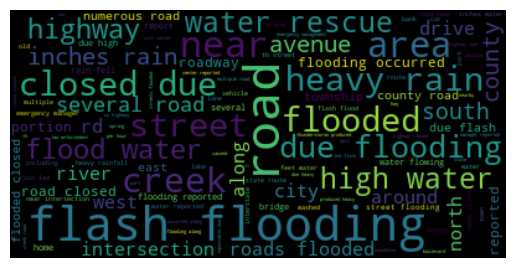

In [42]:
# word cloud - just update the dataframe name!
from wordcloud import WordCloud

wordcloud = WordCloud(max_font_size=40).generate(' '.join(flood_df['EVENT_NARRATIVE'].explode()))
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Making a text classification algorithm
* Put the hail_df and flood_df together as one big dataset (they have similar numbers of observations)
* Decide on how to create features for modeling (Bag of Words vs. TF-IDF)
* Split the data into test or train partitions
* Fit a classification model!
* Check out the error metrics

Try doing this with EPISODE_NARRATIVE vs. stemmed EVENT_NARRATIVE we created. We get interesting results depending on what we choose.

### Merge the Data (tmpdf)...
Just appending the hail_df rows and flood_df rows.

In [43]:
# first, just appened the datasets you made

print(hail_df.shape)
print(flood_df.shape)

tmpdf = pd.concat([hail_df, flood_df], ignore_index=True, axis=0)
print(tmpdf.shape)

(3783, 29)
(3851, 29)
(7634, 29)


In [44]:
# check it out!
tmpdf.info()
tmpdf.head()

<class 'pandas.DataFrame'>
RangeIndex: 7634 entries, 0 to 7633
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EPISODE_ID         7634 non-null   int64  
 1   EVENT_ID           7634 non-null   int64  
 2   STATE              7634 non-null   str    
 3   STATE_FIPS         7634 non-null   int64  
 4   YEAR               7634 non-null   int64  
 5   MONTH_NAME         7634 non-null   str    
 6   EVENT_TYPE         7634 non-null   str    
 7   CZ_NAME            7634 non-null   str    
 8   BEGIN_DATE_TIME    7634 non-null   str    
 9   CZ_TIMEZONE        7634 non-null   str    
 10  END_DATE_TIME      7634 non-null   str    
 11  INJURIES_DIRECT    7634 non-null   int64  
 12  INJURIES_INDIRECT  7634 non-null   int64  
 13  DEATHS_DIRECT      7634 non-null   int64  
 14  DEATHS_INDIRECT    7634 non-null   int64  
 15  DAMAGE_PROPERTY    6647 non-null   str    
 16  DAMAGE_CROPS       6713 non-null   

,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_NAME,BEGIN_DATE_TIME,CZ_TIMEZONE,...,BEGIN_LOCATION,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,Stemmed
0,141212,848333,VERMONT,50,2019,September,Hail,WINDSOR,9/4/2019 12:29,EST-5,...,LUDLOW,W,LUDLOW,43.40,-72.72,43.40,-72.72,A strong mid-level disturbance and cold front ...,"[quarter, size, hail, reported, okemo, ski, re...","[quarter, size, hail, report, okemo, ski, resort]"
1,139926,844159,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:37,MST-7,...,FROID,ENE,FROID,48.39,-104.26,48.39,-104.26,Plentiful surface moisture from the southeast ...,"[trained, spotter, reported, hail, size, quart...","[train, spotter, report, hail, size, quarter, ..."
2,139926,844160,MONTANA,30,2019,September,Hail,ROOSEVELT,9/2/2019 8:50,MST-7,...,FROID,ENE,FROID,48.39,-104.29,48.39,-104.29,Plentiful surface moisture from the southeast ...,"[public, reported, via, social, media, quarter...","[public, report, via, social, media, quarter, ..."
3,139926,844158,MONTANA,30,2019,September,Hail,SHERIDAN,9/2/2019 7:27,MST-7,...,PLENTYWOOD,WSW,PLENTYWOOD,48.72,-104.74,48.72,-104.74,Plentiful surface moisture from the southeast ...,"[public, reported, quarter, size, hail]","[public, report, quarter, size, hail]"
4,141962,852318,CONNECTICUT,9,2019,September,Hail,HARTFORD,9/4/2019 16:10,EST-5,...,ENFIELD,N,ENFIELD,41.97,-72.57,41.97,-72.57,A cold front pushed through southern New Engla...,"[dime, size, hail, reported, enfield]","[dime, size, hail, report, enfield]"


### Clean up the stemmed column into something useable for modeling
Let's get rid of the square brackets and leave it as a regular, cleaned up text column.

In [45]:
# here's what it looked like before
tmpdf['Stemmed'].head()

0    [quarter, size, hail, report, okemo, ski, resort]
1    [train, spotter, report, hail, size, quarter, ...
2    [public, report, via, social, media, quarter, ...
3                [public, report, quarter, size, hail]
4                  [dime, size, hail, report, enfield]
Name: Stemmed, dtype: object

In [46]:
# link: https://pythonhealthcare.org/2018/12/14/101-pre-processing-data-tokenization-stemming-and-removal-of-stop-words/
# try to change
def rejoin_words(row):
    my_list = row['Stemmed']
    joined_words = ( " ".join(my_list))
    return joined_words

tmpdf['Stemmed'] = tmpdf.apply(rejoin_words, axis=1)
# here it is after - no square brackets and commas!
tmpdf['Stemmed'].head()

0            quarter size hail report okemo ski resort
1    train spotter report hail size quarter along h...
2     public report via social media quarter size hail
3                      public report quarter size hail
4                        dime size hail report enfield
Name: Stemmed, dtype: str

### Choose X and Y
This is where you can choose to either use 'Stemmed' or the raw 'EPISODE_NARRATIVE'. We will use 'Stemmed' as the first example - you will use the raw 'EPISODE_NARRATIVE' for your homework.

Both are 100% valid approaches to modeling - one just has a little more pre-processing.

In [47]:
# split into X and Y
X=pd.DataFrame(tmpdf['Stemmed'])
y=tmpdf['EVENT_TYPE']
print(X.shape,y.shape)

(7634, 1) (7634,)


### Split FIRST, then build features
The vocabulary (and later the TF-IDF weights) must be learned from the **training** narratives only - otherwise the test set quietly helps build the features it's graded on.

In [48]:
from sklearn.model_selection import train_test_split

# 60% Training; 20% Validation; 20% Test
X_train_text, X_hold_text, y_train, y_hold = train_test_split(X['Stemmed'], y, test_size=0.4, random_state=5509)
X_val_text, X_test_text, y_val, y_test = train_test_split(X_hold_text, y_hold, test_size=0.5, random_state=5509)
print(X_train_text.shape, X_val_text.shape, X_test_text.shape)

(4580,)

 (1527,) (1527,)


## Create features for modeling: Bag of Words
This will tell you how many times each word was mentioned in a sample.

**Check out the documentation:** https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

[Unigram, bigram, trigram](https://www.google.com/url?sa=i&url=https%3A%2F%2Farshadmehmood.com%2Fdevelopment%2Fgenerate-unigrams-bigrams-trigrams-ngrams-etc-in-python%2F&psig=AOvVaw2DPfI9oyB65ONqb7AEDzM6&ust=1592425067747000&source=images&cd=vfe&ved=0CAIQjRxqFwoTCJChmOeTh-oCFQAAAAAdAAAAABAD) is something you should be comfortable with.


* https://arshadmehmood.com/development/generate-unigrams-bigrams-trigrams-ngrams-etc-in-python/

In [49]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

# get rid of garbage text
token = RegexpTokenizer(r'[a-zA-Z0-9]+')

#tokenizer to remove unwanted elements from out data like symbols and numbers
# IN ONE LINE OF CODE! Let's go for the more detailed description...
cv = CountVectorizer(lowercase=True,
                     stop_words='english',
                     ngram_range = (1,1), # (1,1) is unigram, (1,2) is uni and bigram, (2,2) is just bigram
                     token_pattern = None,       # we pass our OWN tokenizer below, so switch off sklearn's built-in one (this also silences a warning)
                     tokenizer = token.tokenize)
text_counts = cv.fit_transform(X_train_text) # fit on TRAIN only
val_counts = cv.transform(X_val_text)        # validation and test just get transformed
test_counts = cv.transform(X_test_text)
print(text_counts.shape, val_counts.shape, test_counts.shape)

(4580, 4984) (1527, 4984) (1527, 4984)


### Unigrams, bigrams and trigrams - a toy sentence first
A **unigram** is one word, a **bigram** is two words in a row, a **trigram** is three. Bigrams and trigrams put a little word ORDER back into the bag of words: 'the cat' and 'the mat' become different features.

In [50]:
# a toy example first: unigrams, bigrams and trigrams of one short sentence
# (no stop words removed here, so 'the' and 'on' stay in)
toy = ['the cat sat on the mat']

for n in [1, 2, 3]:
    cv_toy = CountVectorizer(ngram_range=(n, n))
    counts = cv_toy.fit_transform(toy)
    print(n, '- grams:', list(cv_toy.get_feature_names_out()))
    print('   counts:', counts.toarray()[0])

# all three at once: this is why n-grams explode on real data
cv_all = CountVectorizer(ngram_range=(1, 3))
cv_all.fit(toy)
print('uni + bi + tri together:', len(cv_all.vocabulary_), 'columns from a 6-word sentence')

1 - grams: ['cat', 'mat', 'on', 'sat', 'the']
   counts: [1 1 1 1 2]
2 - grams: ['cat sat', 'on the', 'sat on', 'the cat', 'the mat']
   counts: [1 1 1 1 1]
3 - grams: ['cat sat on', 'on the mat', 'sat on the', 'the cat sat']
   counts: [1 1 1 1]
uni + bi + tri together: 14 columns from a 6-word sentence


In [51]:
# how many columns do bigrams and trigrams add? (counted on the training text)
total = 0
for n in [1, 2, 3]:
    cv_n = CountVectorizer(lowercase=True, stop_words='english', ngram_range=(n, n), tokenizer=token.tokenize, token_pattern=None)
    cv_n.fit(X_train_text)
    print(n, '- grams:', len(cv_n.vocabulary_))
    total = total + len(cv_n.vocabulary_)
print('all three together:', total, 'columns for', X_train_text.shape[0], 'training rows')

1 - grams: 4984


2 - grams: 21059


3 - grams: 30396
all three together: 56439 columns for 4580 training rows


In [52]:
# inspect text_counts
# check out the first row
print(text_counts)
np.sum(text_counts[1]) # see how many entries there are

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 47333 stored elements and shape (4580, 4984)>
  Coords	Values
  (0, 3583)	1
  (0, 4071)	1
  (0, 1910)	1
  (0, 4776)	1
  (0, 504)	1
  (0, 3982)	1
  (0, 1075)	1
  (0, 1126)	1
  (1, 4736)	1
  (1, 3753)	1
  (1, 1965)	1
  (1, 2190)	1
  (1, 1176)	1
  (2, 1910)	1
  (2, 3753)	1
  (2, 1564)	1
  (2, 4267)	1
  (2, 1014)	1
  (2, 1178)	1
  (2, 1053)	1
  (2, 4690)	1
  (3, 3583)	1
  (3, 4071)	1
  (3, 1910)	1
  (3, 4496)	1
  :	:
  (4576, 3753)	1
  (4576, 682)	1
  (4576, 719)	1
  (4576, 3756)	1
  (4576, 2975)	1
  (4576, 1023)	1
  (4576, 4091)	1
  (4577, 3753)	1
  (4577, 3480)	1
  (4577, 4725)	1
  (4577, 1094)	1
  (4577, 444)	1
  (4577, 622)	1
  (4577, 2604)	1
  (4578, 3696)	1
  (4578, 2959)	1
  (4579, 3583)	1
  (4579, 4071)	1
  (4579, 1910)	1
  (4579, 1564)	1
  (4579, 2863)	1
  (4579, 1361)	1
  (4579, 1016)	1
  (4579, 3875)	1
  (4579, 136)	1


np.int64(5)

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 4 — Bag of words vs TF-IDF with classic ML - and what is it looking at?
- Say it: the 2022 version split X_TRAIN a second time, so 'test' was rows the tree had already memorized - that's where the old perfect 1.0 came from. Fixed: the split happened before any features.
- Decision tree on the counts, honest this time: validation 0.995, test 0.993 (macro F1 0.993). Random forest 0.995. Confusion matrix: 8 misses out of 1,527.
- Don't celebrate - ask WHY. feature_importances_: hail, flood, size, water, road on top.
- forest_without(): take 'hail', 'flood', 'flash' away -> 0.977, and it just switches to size, water, road. Take the next tier away too -> 0.944, now close, report, street, creek. The two storms use different vocabularies all the way down: easy data, not a brilliant model.
- TF-IDF toy first (the two planet sentences): 'is', 'the', 'planet' are in both -> IDF 1.00; 'earth', 'sun', 'jupiter' in one -> 1.41. Then the formula; sklearn smooths (+1) and scales each row to length 1, so hand math won't match to the decimal.
- TF-IDF = term frequency x log(documents / documents containing the word): crushes words that are everywhere, boosts rare-but-telling ones. Fit on train: 4,580 x 5,054; row 0 has 8 non-zeros.
- TF-IDF tree: test 0.988; forest 0.997 (macro F1 identical - balanced pair). Seeded, so these match what students get.
- feature_importances_ can't say WHICH storm a word points to - that's SHAP, video 6b. Bridge: Keras does the cleaning + TF-IDF in two lines, next.
-->

## Build a model

In [53]:
# the split already happened, BEFORE we built any features - here are the three pieces
# (the 2022 version split X_train a second time, so 'test' was rows the model had already seen!)
print(text_counts.shape, val_counts.shape, test_counts.shape)

(4580, 4984) (1527, 4984) (1527, 4984)


In [54]:
from sklearn.tree import DecisionTreeClassifier
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

clf = DecisionTreeClassifier(random_state=5509).fit(text_counts, y_train)
predicted = clf.predict(val_counts)
print("DTC validation accuracy:", round(metrics.accuracy_score(y_val, predicted), 3))
predicted = clf.predict(test_counts)
print("DTC test accuracy:", round(metrics.accuracy_score(y_test, predicted), 3))
print("DTC test macro F1:", round(metrics.f1_score(y_test, predicted, average='macro'), 3))

# think of how much time this saves and we didn't even have
# to read any of this, just needed to be careful with our
# data prep and let it rip!

DTC validation accuracy: 0.995
DTC test accuracy: 0.993
DTC test macro F1: 0.993


In [55]:
from sklearn.ensemble import RandomForestClassifier
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

clf = RandomForestClassifier(random_state=5509).fit(text_counts, y_train)
predicted = clf.predict(test_counts)
print("RFC test accuracy:", round(metrics.accuracy_score(y_test, predicted), 3))
print("RFC test macro F1:", round(metrics.f1_score(y_test, predicted, average='macro'), 3))

RFC test accuracy: 0.995
RFC test macro F1: 0.995


In [56]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

 Flash Flood       0.99      1.00      0.99       772
        Hail       1.00      0.99      0.99       755

    accuracy                           0.99      1527
   macro avg       0.99      0.99      0.99      1527
weighted avg       0.99      0.99      0.99      1527



In [57]:
# confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predicted) # only a handful of misses here, wow...

array([[769,   3],
       [  5, 750]])

## What is the forest looking at?
A score this high should make you curious, not happy. `feature_importances_` ranks the words the forest leans on (it can't tell you WHICH storm a word points to - that's what SHAP does, in the next notebook).

hail       0.161479
flood      0.108289
size       0.082458
water      0.070800
road       0.056171
close      0.028984
quarter    0.028015
street     0.018947
flash      0.016663
report     0.016396
highway    0.012623
ball       0.011497
flow       0.010232
creek      0.009075
rescu      0.008199
dtype: float64


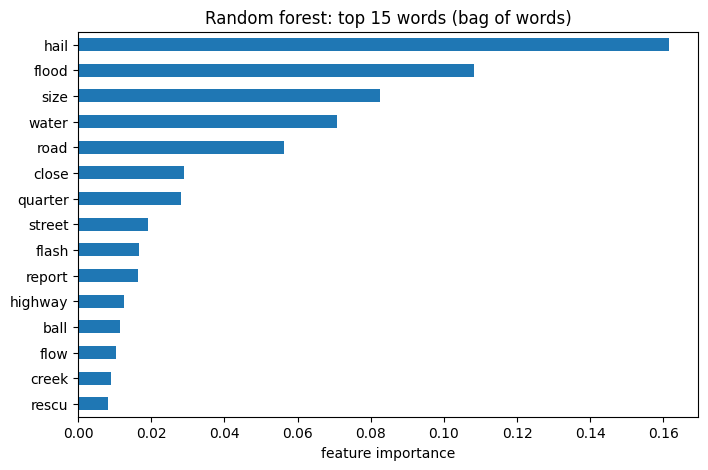

In [58]:
# which words does the forest lean on?
importances = pd.Series(clf.feature_importances_, index=cv.get_feature_names_out())
top_words = importances.sort_values(ascending=False)[0:15]
print(top_words)

top_words.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Random forest: top 15 words (bag of words)')
plt.xlabel('feature importance')
plt.show()

### Would it still work without the giveaway words?
Take the obvious words away, rebuild the bag of words, re-fit the forest - and see what it grabs next.

In [59]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def forest_without(extra_stop_words):
    """Rebuild the bag of words WITHOUT some words, re-fit the forest, score it on the test set."""
    stop_list = list(ENGLISH_STOP_WORDS) + extra_stop_words
    cv_less = CountVectorizer(lowercase=True, stop_words=stop_list, tokenizer=token.tokenize, token_pattern=None)
    train_less = cv_less.fit_transform(X_train_text)
    test_less = cv_less.transform(X_test_text)
    forest = RandomForestClassifier(random_state=5509).fit(train_less, y_train)
    f1 = metrics.f1_score(y_test, forest.predict(test_less), average='macro')
    top = pd.Series(forest.feature_importances_, index=cv_less.get_feature_names_out()).sort_values(ascending=False)[0:5]
    print('removed', extra_stop_words)
    print('   test macro F1:', round(f1, 3), '| now it leans on:', list(top.index))

forest_without([])
forest_without(['hail', 'flood', 'flash'])
forest_without(['hail', 'flood', 'flash', 'size', 'quarter', 'water', 'road', 'inch', 'ball', 'golf', 'rain'])

# the score barely moves: hail and flood reports use DIFFERENT VOCABULARIES all the way down.
# easy data - not a brilliant model.

removed []
   test macro F1: 0.995 | now it leans on: ['hail', 'flood', 'size', 'water', 'road']


removed ['hail', 'flood', 'flash']
   test macro F1: 0.977 | now it leans on: ['size', 'water', 'road', 'quarter', 'close']


removed ['hail', 'flood', 'flash', 'size', 'quarter', 'water', 'road', 'inch', 'ball', 'golf', 'rain']
   test macro F1: 0.944 | now it leans on: ['close', 'report', 'street', 'creek', 'highway']


# Create features for modeling: TF-IDF
Bag of words treats every word the same. But a word that shows up in **every** narrative ('reported', 'the') can't tell a hail storm from a flash flood - and a word that shows up in only a **few** ('golf', 'washed') tells you a lot. **TF-IDF keeps the count, then turns DOWN the words that are everywhere.**

It's two pieces, multiplied together:

* **TF - term frequency:** how many times word *w* appears in document *d*. That's just the bag-of-words count.
* **IDF - inverse document frequency:** how RARE word *w* is across all *N* documents, where *DF(w)* = the number of documents that contain it.

$$IDF(w) = \log\frac{N}{DF(w)}$$

$$TFIDF(w, d) = TF(w, d) \times IDF(w)$$

* A word in **every** document: N / DF(w) = 1, and log(1) = 0 - so its TF-IDF is 0, no matter how often it appears.
* A word in only a **few** documents: N / DF(w) is big, so IDF is big - it counts a lot.

**scikit-learn tweaks this a little.** It uses IDF(w) = log((1 + N) / (1 + DF(w))) + 1, so nothing divides by zero and no word is thrown away completely, and then it scales every row to length 1 so a long narrative doesn't win just by being long. Same idea - just don't expect your hand math to match its numbers to the decimal.

In [60]:
# a toy example first: two short sentences, every number visible (single words only - no bigrams here)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

toy_docs = ['earth is the third planet from the sun',
            'jupiter is the largest planet']
print('sentence 1:', toy_docs[0])
print('sentence 2:', toy_docs[1])

# TF = how many times each word appears in each sentence (plain bag-of-words counts)
toy_counts = CountVectorizer().fit(toy_docs)
tf_counts = toy_counts.transform(toy_docs).toarray()

# TF-IDF with the row scaling switched OFF (norm=None), so every number is exactly TF x IDF
toy_tfidf = TfidfVectorizer(norm=None).fit(toy_docs)
tfidf_values = toy_tfidf.transform(toy_docs).toarray()

# one row per word
toy_table = pd.DataFrame({'TF (sentence 1)': tf_counts[0],
                          'TF (sentence 2)': tf_counts[1],
                          'IDF': toy_tfidf.idf_.round(2),
                          'TF-IDF (sentence 1)': tfidf_values[0].round(2),
                          'TF-IDF (sentence 2)': tfidf_values[1].round(2)},
                         index=toy_tfidf.get_feature_names_out())
toy_table

# read it one row at a time:
#   'the'   - 2 times in sentence 1, 1 time in sentence 2. It's in BOTH sentences -> lowest IDF (1.00) -> TF-IDF 2 x 1.00 = 2.00 and 1.00
#   'earth' - once, and ONLY in sentence 1 -> higher IDF (1.41) -> TF-IDF 1 x 1.41 = 1.41 in sentence 1, 0 in sentence 2
# every TF-IDF number is just TF x IDF. The real TfidfVectorizer below ALSO scales each row to length 1 - that's the only difference.

sentence 1: earth is the third planet from the sun
sentence 2: jupiter is the largest planet


,TF (sentence 1),TF (sentence 2),IDF,TF-IDF (sentence 1),TF-IDF (sentence 2)
earth,1,0,1.41,1.41,0.00
from,1,0,1.41,1.41,0.00
is,1,1,1.00,1.00,1.00
jupiter,0,1,1.41,0.00,1.41
largest,0,1,1.41,0.00,1.41
planet,1,1,1.00,1.00,1.00
sun,1,0,1.41,1.41,0.00
the,2,1,1.00,2.00,1.00
third,1,0,1.41,1.41,0.00


In [61]:
# create the matrix - fit on TRAIN only, same split as before
# every keyword argument below is scikit-learn's default - they're spelled out so you can see (and play with) the knobs
tf = TfidfVectorizer(lowercase=True,       # 'Hail' = 'hail' (our text is already lowercase, but it doesn't hurt)
                     ngram_range=(1, 1),   # single words only - try (1, 2) to add bigrams!
                     smooth_idf=True,      # the +1 trick: nothing divides by zero, no word gets thrown away completely
                     norm='l2')            # scale each row to length 1, so a long narrative doesn't win by being long
text_tf = tf.fit_transform(X_train_text)   # learn the vocabulary AND each word's IDF from TRAIN only
val_tf = tf.transform(X_val_text)          # validation and test just get transformed with the TRAIN IDFs
test_tf = tf.transform(X_test_text)

In [62]:
# check out what you did
text_tf.shape # one column per word in the TRAINING narratives

(4580, 5054)

### What does one row of TF-IDF look like?
Every narrative becomes one row with **5,054 columns** - one per word in the training vocabulary. Almost all of them are 0 (a narrative only uses a handful of words), so Python stores just the non-zero entries. That's what **sparse** means.

`print(text_tf[0])` lists those non-zero entries for the first training narrative. Each line is `(row, column)  value`:
* **row** - which narrative (0 = the first one)
* **column** - which word in the vocabulary (just a number for now)
* **value** - that word's TF-IDF in this narrative

The cell after it turns the column numbers back into words.

In [63]:
# the first training narrative (stemmed), then its non-zero TF-IDF entries
print(X_train_text.iloc[0])
print()
print(text_tf[0])

quarter size hail west bradi sever crop damag

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (1, 5054)>
  Coords	Values
  (0, 3632)	0.22830468732533624
  (0, 4125)	0.16908648269162938
  (0, 1942)	0.14355554921495156
  (0, 4842)	0.3305768130323892
  (0, 516)	0.6357106814953597
  (0, 4033)	0.260521994677021
  (0, 1089)	0.4713614290623655
  (0, 1140)	0.30857110850773484


In [64]:
# the same row, with the words spelled out, biggest weight first
row0 = pd.Series(text_tf[0].toarray()[0], index=tf.get_feature_names_out())
row0[row0 > 0].sort_values(ascending=False).round(3)

bradi      0.636
crop       0.471
west       0.331
damag      0.309
sever      0.261
quarter    0.228
size       0.169
hail       0.144
dtype: float64

In [65]:
# fit a model
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

clf = DecisionTreeClassifier(random_state=5509).fit(text_tf, y_train)
predicted = clf.predict(test_tf)
print("DTC test accuracy:", round(metrics.accuracy_score(y_test, predicted), 3))
print("DTC test macro F1:", round(metrics.f1_score(y_test, predicted, average='macro'), 3))

DTC test accuracy: 0.988
DTC test macro F1: 0.988


In [66]:
# fit a model
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

clf = RandomForestClassifier(random_state=5509).fit(text_tf, y_train)
predicted = clf.predict(test_tf)
print("RFC test accuracy:", round(metrics.accuracy_score(y_test, predicted), 3))
print("RFC test macro F1:", round(metrics.f1_score(y_test, predicted, average='macro'), 3))

RFC test accuracy: 0.997
RFC test macro F1: 0.997


# Thoughts
TF-IDF is interesting - and it is essentially a glorified form of feature engineering.

We can use more condensed code to fit the TF_IDF with a feedforward neural network.
**Link:** https://www.kaggle.com/welgum/tf-idf-with-simple-nn-keras

Later on, we can consider (1) one-hot encoding for use in a neural network or (2) learn word embeddings which we can either flatten or incorporate into the LSTM and (3) import pre-learned word embeddings for help 'hot-rod' our models.

In [67]:
# we can start this in another notebook